# The Euler–Maruyama Method

This notebook accompanies the lecture notes on the Euler–Maruyama method for
stochastic differential equations (SDEs). We work through the key computational
demonstrations from Higham (2001), building from Brownian motion simulation
to convergence experiments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 12})

## 1. Simulating Brownian Motion

Brownian motion $W(t)$ has increments $\Delta W = \sqrt{h}\,Z$ where
$Z \sim \mathcal{N}(0,1)$. We build a path by cumulative summation of
these increments.

**Run this cell several times.** Each run gives a different path — that's
the point.

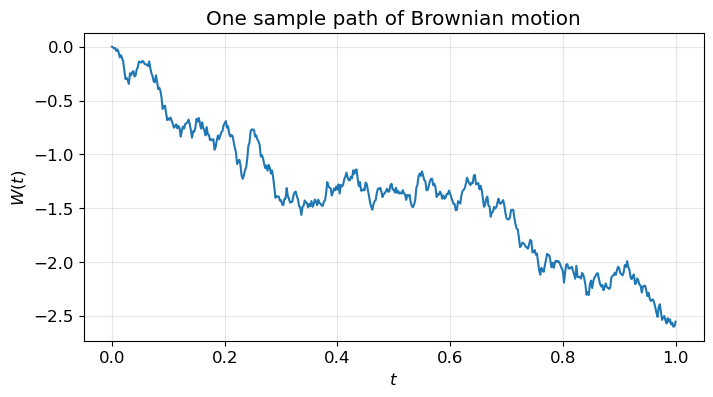

In [2]:
N = 500
dt = 1.0 / N
dW = np.sqrt(dt) * np.random.randn(N)
W = np.cumsum(dW)
W = np.insert(W, 0, 0.0)  # W(0) = 0

plt.plot(np.linspace(0, 1, N + 1), W)
plt.xlabel("$t$")
plt.ylabel("$W(t)$")
plt.title("One sample path of Brownian motion")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Monte Carlo Verification of Increment Properties

The two key properties of Brownian increments are:

$$\mathbb{E}[\Delta W] = 0, \qquad \mathbb{E}[(\Delta W)^2] = h$$

We verify these by sampling many increments and computing sample means.

In [3]:
# Standard normal: E[Z] = 0, E[Z^2] = 1
Z = np.random.randn(100_000)
print(f"E[Z]   ≈ {np.mean(Z):.4f}   (exact: 0)")
print(f"E[Z²]  ≈ {np.mean(Z**2):.4f}   (exact: 1)")

E[Z]   ≈ 0.0015   (exact: 0)
E[Z²]  ≈ 1.0015   (exact: 1)


In [4]:
# Scaled increments: E[ΔW] = 0, E[(ΔW)²] = h
h = 0.01
dW_samples = np.sqrt(h) * np.random.randn(100_000)
print(f"E[ΔW]    ≈ {np.mean(dW_samples):.6f}   (exact: 0)")
print(f"E[(ΔW)²] ≈ {np.mean(dW_samples**2):.6f}   (exact: {h})")

E[ΔW]    ≈ -0.000011   (exact: 0)
E[(ΔW)²] ≈ 0.010105   (exact: 0.01)


## 3. Itô vs Stratonovich Integrals

For ordinary integrals, left-endpoint and midpoint Riemann sums converge to
the same limit. For stochastic integrals, they do **not**.

Consider $\int_0^T W(t)\,dW(t)$:

- **Itô** (left endpoint): $\frac{1}{2}W(T)^2 - \frac{1}{2}T$
- **Stratonovich** (midpoint): $\frac{1}{2}W(T)^2$

The difference $\frac{1}{2}T$ is real and does not vanish as $N \to \infty$.

This follows Higham's `stint.m` program.

In [5]:
N = 500
T = 1.0
dt = T / N
dW = np.sqrt(dt) * np.random.randn(N)
W = np.cumsum(dW)
W_prev = np.insert(W[:-1], 0, 0.0)  # [0, W_0, W_1, ..., W_{N-2}]

# Itô integral (left-endpoint sum)
ito = np.sum(W_prev * dW)
ito_exact = 0.5 * W[-1] ** 2 - 0.5 * T
print(f"Itô sum:   {ito:.4f},  exact: {ito_exact:.4f},  error: {abs(ito - ito_exact):.4f}")

# Stratonovich integral (midpoint sum)
W_mid = 0.5 * (W_prev + W) + 0.5 * np.sqrt(dt) * np.random.randn(N)
strat = np.sum(W_mid * dW)
strat_exact = 0.5 * W[-1] ** 2
print(f"Strat sum: {strat:.4f},  exact: {strat_exact:.4f},  error: {abs(strat - strat_exact):.4f}")

Itô sum:   -0.4789,  exact: -0.4346,  error: 0.0443
Strat sum: 0.0779,  exact: 0.0654,  error: 0.0125


## 4. Euler–Maruyama for Geometric Brownian Motion

We apply Euler–Maruyama to geometric Brownian motion:

$$dX = \lambda X\,dt + \mu X\,dW, \qquad X(0) = X_0$$

The exact solution is
$X(t) = X_0 \exp\!\left[(\lambda - \tfrac{1}{2}\mu^2)t + \mu\,W(t)\right]$,
so we can compare numerical and exact solutions on the **same Brownian path**.

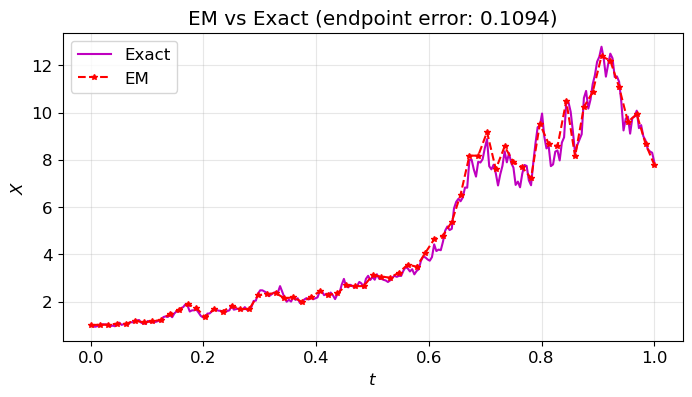

In [6]:
# Parameters
lam = 2.0
mu = 1.0
X0 = 1.0
T = 1.0

# Fine Brownian path ("truth" grid)
N = 2**8
dt = T / N
dW = np.sqrt(dt) * np.random.randn(N)
W = np.cumsum(dW)
t_fine = np.linspace(dt, T, N)

# Exact solution along this Brownian path
Xtrue = X0 * np.exp((lam - 0.5 * mu**2) * t_fine + mu * W)

# Euler–Maruyama with coarser step size
R = 4  # use every R-th sub-step
Dt = R * dt
L = N // R
Xem = np.zeros(L)
Xtemp = X0
for j in range(L):
    # Sum fine Brownian increments to get the EM increment
    Winc = np.sum(dW[R * j : R * (j + 1)])
    Xtemp = Xtemp + lam * Xtemp * Dt + mu * Xtemp * Winc
    Xem[j] = Xtemp

# Plot
t_em = np.linspace(Dt, T, L)
plt.plot(np.insert(t_fine, 0, 0), np.insert(Xtrue, 0, X0), "m-", label="Exact")
plt.plot(np.insert(t_em, 0, 0), np.insert(Xem, 0, X0), "r--*", label="EM", markersize=4)
plt.xlabel("$t$")
plt.ylabel("$X$")
plt.legend()
plt.title(f"EM vs Exact (endpoint error: {abs(Xem[-1] - Xtrue[-1]):.4f})")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Strong Convergence Experiment

We verify that $\mathbb{E}|X_N - X(T)| = O(h^{1/2})$ by running many
independent simulations at several step sizes and plotting the mean endpoint
error on a log-log scale. The slope should be approximately $1/2$.

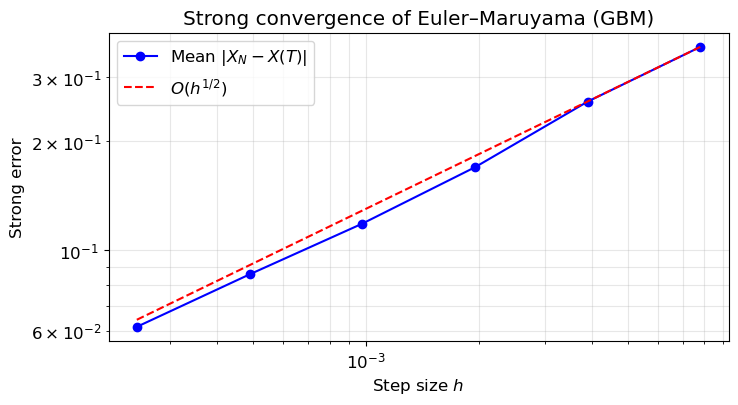

Estimated strong convergence order: 0.517  (expected ≈ 0.5)


In [7]:
lam = 2.0
mu = 1.0
X0 = 1.0
T = 1.0
M = 1000  # number of Monte Carlo samples

# Fine grid for "exact" solution
N_fine = 2**12
dt_fine = T / N_fine

# Step sizes to test (coarsen by factors of 2)
R_values = np.array([1, 2, 4, 8, 16, 32])
Dt_values = R_values * dt_fine
strong_errors = np.zeros(len(R_values))

for m in range(M):
    # Generate one fine Brownian path
    dW = np.sqrt(dt_fine) * np.random.randn(N_fine)
    W_T = np.sum(dW)
    # Exact solution at T
    Xtrue_T = X0 * np.exp((lam - 0.5 * mu**2) * T + mu * W_T)

    for i, R in enumerate(R_values):
        Dt = R * dt_fine
        L = N_fine // R
        Xtemp = X0
        for j in range(L):
            Winc = np.sum(dW[R * j : R * (j + 1)])
            Xtemp = Xtemp + lam * Xtemp * Dt + mu * Xtemp * Winc
        strong_errors[i] += np.abs(Xtemp - Xtrue_T)

strong_errors /= M

# Plot
plt.loglog(Dt_values, strong_errors, "bo-", label="Mean $|X_N - X(T)|$")
# Reference line with slope 1/2
c = strong_errors[-1] / np.sqrt(Dt_values[-1])
plt.loglog(Dt_values, c * np.sqrt(Dt_values), "r--", label="$O(h^{1/2})$")
plt.xlabel("Step size $h$")
plt.ylabel("Strong error")
plt.legend()
plt.title("Strong convergence of Euler–Maruyama (GBM)")
plt.grid(True, alpha=0.3, which="both")
plt.show()

# Compute slope
slope = np.polyfit(np.log(Dt_values), np.log(strong_errors), 1)[0]
print(f"Estimated strong convergence order: {slope:.3f}  (expected ≈ 0.5)")

## 6. Weak Convergence Experiment

We verify that $|\mathbb{E}[X_N] - \mathbb{E}[X(T)]| = O(h)$.

For GBM, $\mathbb{E}[X(T)] = X_0 e^{\lambda T}$ (the noise averages out
in expectation). We estimate $\mathbb{E}[X_N]$ by Monte Carlo and compare.

**Key difference from the strong experiment:** each sample uses an
*independent* Brownian path (we don't need to track the same path).

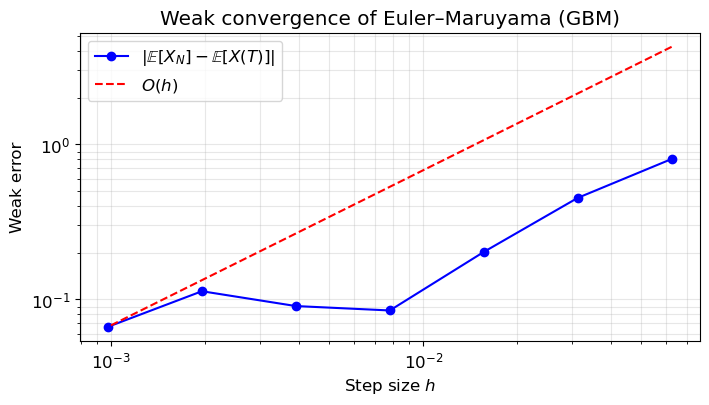

Estimated weak convergence order: 0.569  (expected ≈ 1.0)


In [8]:
lam = 2.0
mu = 1.0
X0 = 1.0
T = 1.0
M = 50_000  # more samples needed for weak error (smaller quantity)

# Exact expected value: E[X(T)] = X0 * exp(lam * T)
E_exact = X0 * np.exp(lam * T)

# Step sizes to test
N_values = np.array([2**p for p in range(4, 11)])
Dt_values = T / N_values
weak_errors = np.zeros(len(N_values))

for i, Nsteps in enumerate(N_values):
    Dt = T / Nsteps
    # Vectorized over M samples
    X = X0 * np.ones(M)
    for j in range(Nsteps):
        dW = np.sqrt(Dt) * np.random.randn(M)
        X = X + lam * X * Dt + mu * X * dW
    weak_errors[i] = np.abs(np.mean(X) - E_exact)

# Plot
plt.loglog(Dt_values, weak_errors, "bo-", label=r"$|\mathbb{E}[X_N] - \mathbb{E}[X(T)]|$")
# Reference line with slope 1
c = weak_errors[-1] / Dt_values[-1]
plt.loglog(Dt_values, c * Dt_values, "r--", label="$O(h)$")
plt.xlabel("Step size $h$")
plt.ylabel("Weak error")
plt.legend()
plt.title("Weak convergence of Euler–Maruyama (GBM)")
plt.grid(True, alpha=0.3, which="both")
plt.show()

# Compute slope
slope = np.polyfit(np.log(Dt_values), np.log(weak_errors), 1)[0]
print(f"Estimated weak convergence order: {slope:.3f}  (expected ≈ 1.0)")